In [1]:
%matplotlib inline
import numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
np.random.seed(0); torch.manual_seed(0)
print("torch", torch.__version__)

torch 2.12.0+cpu


In [2]:
BASES="ACGT"; IDX={b:i for i,b in enumerate(BASES)}
COMP={"A":"T","T":"A","C":"G","G":"C","N":"N"}
MOTIF="CCGCGNGGNGGCAG"
def revcomp(m): return "".join(COMP[b] for b in m[::-1])
def one_hot(s):
    x=np.zeros((4,len(s)),np.float32)
    for j,b in enumerate(s): x[IDX[b],j]=1
    return x

SEQ_LEN=512; NB=16; BIN=SEQ_LEN//NB
def background(nb):                       # weak contact decay with genomic distance
    i=np.arange(nb); return 0.2*np.exp(-np.abs(i[:,None]-i[None,:])/4.0)

def make_sample():
    seq=list("".join(np.random.choice(list(BASES),SEQ_LEN)))
    sites=[]
    for _ in range(np.random.randint(1,4)):
        b=np.random.randint(0,NB); o=np.random.choice([1,-1])
        m=MOTIF if o==1 else revcomp(MOTIF)
        m="".join(np.random.choice(list(BASES)) if ch=="N" else ch for ch in m)
        p=b*BIN+(BIN-len(m))//2; seq[p:p+len(m)]=list(m); sites.append((b,o))
    C=background(NB)
    for a,oa in sites:                    # convergent pair (fwd..rev) -> bright dot + domain
        for d,od in sites:
            if a<d and oa==1 and od==-1:
                C[a,d]+=2.0; C[d,a]+=2.0; C[a:d+1,a:d+1]+=0.4
    C=np.clip(C,0,3.0).astype(np.float32)
    return one_hot("".join(seq)), C, sites

Xs, Ys = [], []
for _ in range(2500):
    x,cmap,_=make_sample(); Xs.append(x); Ys.append(cmap)
Xs=np.stack(Xs); Ys=np.stack(Ys)
print("sequences:", Xs.shape, "| contact maps:", Ys.shape)

sequences: (2500, 4, 512) | contact maps: (2500, 16, 16)


In [3]:
ntr=2000
Xtr,Xte=torch.tensor(Xs[:ntr]),torch.tensor(Xs[ntr:])
Ytr,Yte=torch.tensor(Ys[:ntr]),torch.tensor(Ys[ntr:])
print("train:",Xtr.shape,"test:",Xte.shape)

train: torch.Size([2000, 4, 512]) test: torch.Size([500, 4, 512])


In [4]:
class MiniAkita(nn.Module):
    def __init__(s,d=32,nb=NB):
        super().__init__()
        s.enc=nn.Sequential(nn.Conv1d(4,48,15,padding=7),nn.ReLU(),
                            nn.Conv1d(48,d,15,padding=7),nn.ReLU(),
                            nn.AdaptiveMaxPool1d(nb))       # max-pool keeps motif/orientation signal
        s.head=nn.Sequential(nn.Linear(2*d+2,64),nn.ReLU(),nn.Linear(64,1))
        s.register_buffer("pos",torch.linspace(0,1,nb))
    def forward(s,x):
        E=s.enc(x).transpose(1,2)                           # (B, nb, d)
        B,nb,d=E.shape
        Ei=E[:,:,None,:].expand(B,nb,nb,d)
        Ej=E[:,None,:,:].expand(B,nb,nb,d)
        pi=s.pos[None,:,None,None].expand(B,nb,nb,1)
        pj=s.pos[None,None,:,None].expand(B,nb,nb,1)
        M=s.head(torch.cat([Ei,Ej,pi,pj],-1)).squeeze(-1)  # (B, nb, nb); pos lets it use bin order
        return 0.5*(M+M.transpose(1,2))
model=MiniAkita(); opt=torch.optim.Adam(model.parameters(),3e-3); lf=nn.MSELoss()
print("params:",sum(p.numel() for p in model.parameters()))

params: 30353


In [5]:
hist=[]
for e in range(60):
    o=torch.randperm(len(Xtr)); tot=0.0
    for i in range(0,len(Xtr),64):
        j=o[i:i+64]; opt.zero_grad(); L=lf(model(Xtr[j]),Ytr[j]); L.backward(); opt.step()
        tot+=L.item()*len(j)
    hist.append(tot/len(Xtr))
    if (e+1)%10==0: print(f"epoch {e+1:2d}/60  MSE {hist[-1]:.4f}")

epoch 10/60  MSE 0.0206


epoch 20/60  MSE 0.0150


epoch 30/60  MSE 0.0095


epoch 40/60  MSE 0.0067


epoch 50/60  MSE 0.0048


epoch 60/60  MSE 0.0037


test MSE: 0.0268


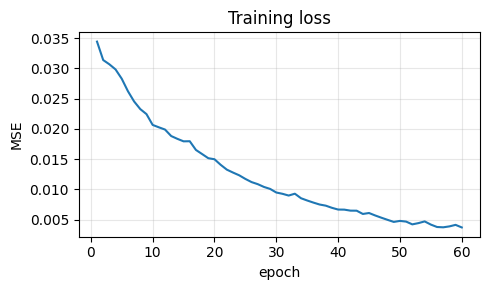

In [6]:
with torch.no_grad(): Pte=model(Xte)
print("test MSE:", round(float(lf(Pte,Yte)),4))
plt.figure(figsize=(5,3)); plt.plot(range(1,61),hist); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("Training loss"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

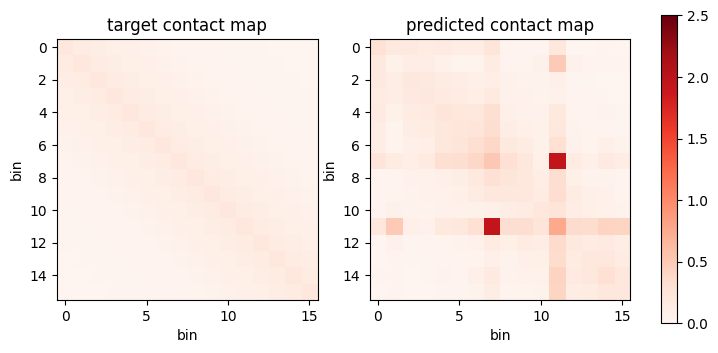

In [7]:
k=0
fig,ax=plt.subplots(1,2,figsize=(8,4))
for a,(img,t) in zip(ax,[(Yte[k],"target"),(Pte[k].detach(),"predicted")]):
    im=a.imshow(img,cmap="Reds",vmin=0,vmax=2.5); a.set_title(t+" contact map"); a.set_xlabel("bin"); a.set_ylabel("bin")
fig.colorbar(im,ax=ax,fraction=0.025); plt.show()

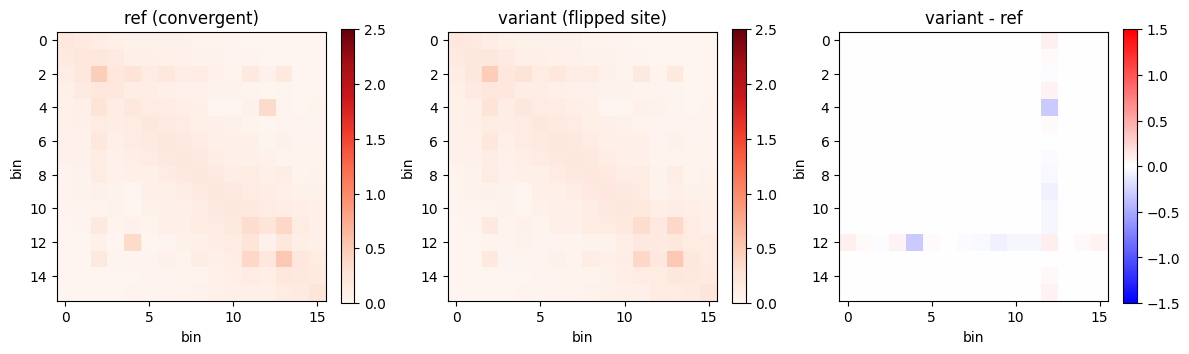

predicted loop-anchor contact (bin4,bin12):  ref = 0.35  ->  variant = 0.04
mean |change| across map: 0.0077
flipping the downstream CTCF site (convergent -> divergent) erases the predicted loop.


In [8]:
def predict_map(seq):
    with torch.no_grad(): return model(torch.tensor(one_hot(seq)[None]))[0].numpy()

# build one sequence with a convergent pair -> then flip the right site (structural variant)
seq=list("".join(np.random.choice(list(BASES),SEQ_LEN)))
def place(seq,bin_,orient):
    m=MOTIF if orient==1 else revcomp(MOTIF)
    m="".join(np.random.choice(list(BASES)) if ch=="N" else ch for ch in m)
    p=bin_*BIN+(BIN-len(m))//2; seq[p:p+len(m)]=list(m); return seq
seq=place(seq,4,1); seq=place(seq,12,-1)          # convergent (fwd@4, rev@12)
ref="".join(seq)
var=list(ref); var=place(var,12,1)                 # variant: flip @12 to fwd -> now divergent
variant="".join(var)
Mref, Mvar = predict_map(ref), predict_map(variant)

fig,ax=plt.subplots(1,3,figsize=(12,4))
for a,(img,t,cm,vlim) in zip(ax,[(Mref,"ref (convergent)","Reds",(0,2.5)),
                                 (Mvar,"variant (flipped site)","Reds",(0,2.5)),
                                 (Mvar-Mref,"variant - ref","bwr",(-1.5,1.5))]):
    im=a.imshow(img,cmap=cm,vmin=vlim[0],vmax=vlim[1]); a.set_title(t); a.set_xlabel("bin"); a.set_ylabel("bin")
    fig.colorbar(im,ax=a,fraction=0.046)
plt.tight_layout(); plt.show()
print(f"predicted loop-anchor contact (bin4,bin12):  ref = {Mref[4,12]:.2f}  ->  variant = {Mvar[4,12]:.2f}")
print("mean |change| across map:", round(float(np.abs(Mvar-Mref).mean()),4))
print("flipping the downstream CTCF site (convergent -> divergent) erases the predicted loop.")